In [1]:
%pylab inline
import pycbc.inject

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [167]:
import pycbc.waveform
from pycbc.waveform import get_fd_waveform,get_td_waveform
from pycbc.filter import sigmasq
import pycbc.psd
from pycbc.detector import Detector

In [3]:
from pycbc import DYN_RANGE_FAC

In [4]:
inj = pycbc.inject.inject._XMLInjectionSet("../injection.xml")
params = {_p: list(inj.table.getColumnByName(_p))[0] for _p in inj.table.columnnames}

In [5]:
wf_param_names = ["mass1", "mass2", "inclination", "waveform", 
                  "coa_phase", "distance", "f_lower", "f_final",
                 'spin1x', 'spin1y', 'spin1z', 'spin2x', 'spin2y', 
                  'spin2z'] 
wf_params = {("approximant" if k == "waveform" else k): 
             (params[k].split("pseudo")[0] if k == "waveform" else params[k])
             for k in wf_param_names
            }
det_params = {
    "t_gps": params["geocent_end_time"],
    "right_ascension": params["longitude"],
    "declination": params["latitude"],
    "polarization": params["polarization"],
}
wf_params["distance"] /= DYN_RANGE_FAC

In [241]:
dets = ["H1", "L1", "V1"]
sample_rate = 512
segment_length = 16
strain_high_pass = 15
tlen = int(sample_rate*segment_length)
delta_t = 1 / sample_rate
length = int(tlen/2) + 1
delta_f = 1 / (tlen * delta_t)
f_final = sample_rate / 2
delta_f = 1 / segment_length
f_lower = wf_params["f_lower"]

(7e-06, 0.01)

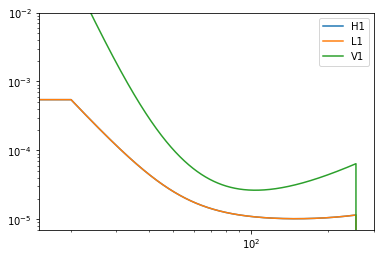

In [154]:
psds = {
    "H1": (pycbc.psd.aLIGOaLIGOO3LowT1800545(length, delta_f, f_lower) * DYN_RANGE_FAC ** 2).astype(float32),
    "L1": (pycbc.psd.aLIGOaLIGOO3LowT1800545(length, delta_f, f_lower) * DYN_RANGE_FAC ** 2).astype(float32),
    "V1": (pycbc.psd.aLIGOAdVO3LowT1800545(length, delta_f, f_lower) * DYN_RANGE_FAC ** 2).astype(float32),
}
# # Set values < flow to the value at flow
kmin = int(f_lower / delta_f)
for _p in psds.values():
    _p[0:kmin] = _p[kmin]

for det in dets:
    loglog(psds[det].sample_frequencies, psds[det], label=det)
legend()
xlim(15, 300)
ylim(7e-6, 1e-2)

In [166]:
td_wf_params = {k:v for k, v in wf_params.items() if k != "f_final"}
td_wf_params["approximant"] = "SEOBNRv4HM"
td_wf_params

{'mass1': 150.0,
 'mass2': 30.0,
 'inclination': 1.570796370506287,
 'approximant': 'SEOBNRv4HM',
 'coa_phase': 0.0,
 'distance': 1.6940658945086007e-19,
 'f_lower': 20.0,
 'spin1x': 0.0,
 'spin1y': 0.0,
 'spin1z': 0.0,
 'spin2x': 0.0,
 'spin2y': 0.0,
 'spin2z': 0.0}

# Time domain injeciton

In [246]:
import pycbc.strain

In [247]:
hp, hc = get_td_waveform(
    **{k:v for k, v in td_wf_params.items() if k != "f_final"}, 
    delta_t=delta_t,
#     f_final=f_final,
)
hp, hc = hp.astype(float32), hc.astype(float32)
    
network_sigma = 0
strain, stilde = {}, {}
sigma_inj = {}
for det in dets:
    ifo = Detector(det)
    fp, fc = ifo.antenna_pattern(**det_params)
    h = zeros(tlen)
    h[3000:3000+len(hp)] = hp*fp+hc*fc
    strain[det] = pycbc.types.TimeSeries(h, delta_t=delta_t, dtype=float32)
    strain[det] = highpass(strain[det], strain_high_pass)

    taper_data = 1
    gate_params = [(strain[det].start_time, 0., taper_data)]
    gate_params.append((strain[det].end_time, 0., taper_data))
    pycbc.strain.gate_data(strain[det], gate_params)
    
    stilde[det] = make_frequency_series(strain[det])
    ss = sigmasq(stilde[det], psds[det], f_lower, f_final)
    sigma_inj[det] = sqrt(ss)
    network_sigma += ss
network_sigma = sqrt(network_sigma)
network_sigma

63.18537589988032

## Frequency domain injection

In [149]:
hp, hc = get_fd_waveform(
    **{k:v for k, v in wf_params.items() if k != "f_final"}, 
    delta_f=delta_f,
    f_final=f_final,
    mode_array=None,
#     pycbc.waveform.mode_array_map(
#         [
#          "22",
#          "33",
#          "44",
#          "21",
#          "32",
#          "43"
#         ]
#         , wf_params["approximant"])
)
hp, hc = hp.astype(complex64), hc.astype(complex64)
    
network_sigma = 0
stilde = {}
sigma_inj = {}
for det in dets:
    ifo = Detector(det)
    fp, fc = ifo.antenna_pattern(**det_params)
    stilde[det] = hp*fp+hc*fc
    ss = sigmasq(stilde[det], psds[det], f_lower, f_final)
    sigma_inj[det] = sqrt(ss)
    network_sigma += ss
network_sigma = sqrt(network_sigma)
network_sigma

76.43609173009719

In [119]:
1187008882.0 + ifo.time_delay_from_earth_center(**{k:v for k,v in det_params.items() if k != "polarization"}), ifo.name

(1187008881.996231, 'V1')

In [121]:
ifo.time_delay_from_earth_center(**{k:v for k,v in det_params.items() if k != "polarization"})

-0.003768942535945425

In [122]:
for det in dets:
    ifo = Detector(det)
    print(1187008882.0 + ifo.time_delay_from_earth_center(**{k:v for k,v in det_params.items() if k != "polarization"}), ifo.name)

1187008881.978762 H1
1187008881.9811177 L1
1187008881.996231 V1


In [ ]:
{'H1': 1187008881.9785156, 'L1': 1187008881.9804688, 'V1': 1187008881.9960938}

In [12]:
template_mem_dom = pycbc.types.zeros(tlen, dtype=complex64)
template_mem_sub = pycbc.types.zeros(tlen, dtype=complex64)
template_mem_sub_perp = pycbc.types.zeros(tlen, dtype=complex64)

In [225]:
approximant="IMRPhenomHM"
# distance = wf_params["distance"]
distance = 1.0 / DYN_RANGE_FAC
template_dom, template_sub = pycbc.waveform.get_lm_filters(
    template_mem_dom[:length], 
    template_mem_sub[:length], 
    None,
    "22", 
#     "44",
    "33",
    approximant=approximant, f_lower=f_lower, f_final=f_final,
    delta_f=delta_f, delta_t=delta_t, distance=distance, 
    mass1=wf_params["mass1"], mass2=wf_params["mass2"],
)

sigma_dom = {}
sigma_sub = {}
alpha_lm = {}
template_sub_perp = {}
sigma_sub_perp = {}
alpha_lm_perp = {}
for det in dets:
    sigma_dom[det] = sqrt(sigmasq(template_dom, psds[det], f_lower, f_final))
    sigma_sub[det] = sqrt(sigmasq(template_sub, psds[det], f_lower, f_final))
    alpha_lm[det] = sigma_sub[det] / sigma_dom[det]
    template_sub_perp[det], sigma_sub_perp[det] = pycbc.waveform.orthogonalize_subdominant_harmonic(
        psds[det],
        sigma_dom[det],
        sigma_sub[det],
        template_dom,
        template_sub,
        f_lower,
        f_final,
    )
    alpha_lm_perp[det] = sigma_sub_perp[det] / sigma_dom[det]
sigma_dom, sigma_sub, sigma_sub_perp, alpha_lm, alpha_lm_perp

({'H1': 13408.115798492368, 'L1': 13408.115798492368, 'V1': 7004.736901111001},
 {'H1': 7792.522463075393, 'L1': 7792.522463075393, 'V1': 4487.067843242948},
 {'H1': 7767.1823654769405, 'L1': 7767.1823654769405, 'V1': 4442.140890786909},
 {'H1': 0.5811795318736431,
  'L1': 0.5811795318736431,
  'V1': 0.6405762138662576},
 {'H1': 0.5792896244489696, 'L1': 0.5792896244489696, 'V1': 0.634162418017778})

In [46]:
for det in dets:
    print(pycbc.filter.sigma(template_sub_perp[det], psds[det], f_lower, f_final))

0.9999998988377313
0.9999998988377313
1.0000000088029068


In [151]:
det = "V1"
s = pycbc.filter.matched_filter(
    template_dom, 
    stilde[det],
    psd=psds[det],
    low_frequency_cutoff=30,
    high_frequency_cutoff=f_final,
    sigmasq=sigma_dom[det]**2,
)
sort(abs(s.data))

array([1.0234432e-03, 1.0234617e-03, 1.0235471e-03, ..., 1.6402760e+01,
       1.6702393e+01, 1.6805004e+01], dtype=float32)

In [136]:
s.sample_times.data

array([0.00195312, 0.00195312, 0.00195312, ..., 0.00195312, 0.00195312,
       0.00195312])

In [137]:
template_dom.data

array([ 0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
        0.0000000e+00+0.0000000e+00j, ..., -1.1902854e-05-2.8011118e-06j,
       -1.1862206e-05-2.7949773e-06j,  0.0000000e+00+0.0000000e+00j],
      dtype=complex64)

In [152]:
det = "H1"
s = pycbc.filter.matched_filter(
    template_dom, 
    stilde[det]/psds[det],
    psd=None,
    low_frequency_cutoff=f_lower,
    high_frequency_cutoff=f_final,
    sigmasq=sigma_dom[det]**2,
)
sort(abs(s.data))

/Users/camill/projects/pycbc/pycbc/types/array.py:383: RuntimeWarning: invalid value encountered in true_divide
  return self._data / other


array([1.1455050e-02, 1.1455101e-02, 1.1455380e-02, ..., 4.2940132e+01,
       4.3789829e+01, 4.4453621e+01], dtype=float32)

In [143]:
st = (stilde[det]/psds[det])

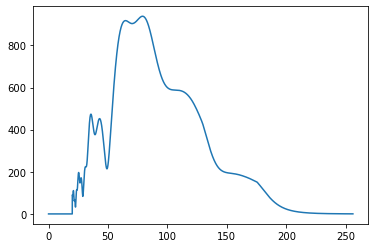

In [153]:
plt.plot(st.sample_frequencies, abs(st))

In [236]:
from pycbc.filter import highpass

(5.8, 6.1)

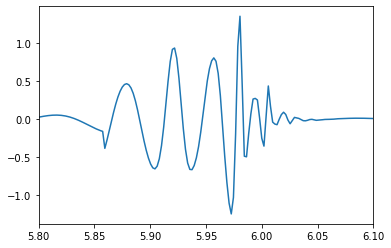

In [252]:
strain["H1"].plot()
xlim(5.8, 6.1)

In [160]:
from pycbc.waveform import td_approximants

In [162]:
from pycbc.filter import make_frequency_series

/Users/camill/projects/pycbc/pycbc/types/array.py:383: RuntimeWarning: divide by zero encountered in true_divide
  return self._data / other
/Users/camill/projects/pycbc/pycbc/types/array.py:383: RuntimeWarning: invalid value encountered in true_divide
  return self._data / other


(15.0, 300.0)

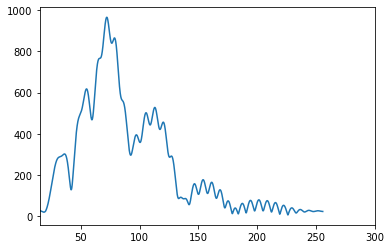

In [231]:
plt.plot(stilde["H1"].sample_frequencies, abs(stilde["H1"] / psds["H1"]))
xlim(15, 300)

In [144]:
st.data

array([ 0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        , ..., -0.30959782+0.0277717j ,
       -0.30833068+0.02749549j,         nan       +nanj], dtype=complex64)

In [145]:
st.sample_frequencies.data

array([0.000000e+00, 6.250000e-02, 1.250000e-01, ..., 2.558750e+02,
       2.559375e+02, 2.560000e+02])

In [139]:
det = "H1"
s = pycbc.filter.matched_filter(
    template_dom, 
    stilde[det],
    psd=psds[det],
    low_frequency_cutoff=f_lower,
    high_frequency_cutoff=f_final,
    sigmasq=sigma_dom[det]**2,
)
sort(abs(s.data))

array([1.1455268e-02, 1.1455282e-02, 1.1455410e-02, ..., 4.2940136e+01,
       4.3789829e+01, 4.4453625e+01], dtype=float32)

In [256]:
snr_dom = {}
snr_sub = {}
snr_sub_perp = {}
for det in dets:
    s = pycbc.filter.matched_filter(
        template_dom, 
        stilde[det],
        psd=psds[det],
        low_frequency_cutoff=f_lower,
        high_frequency_cutoff=f_final,
        sigmasq=sigma_dom[det]**2,
    )
    idx_abs_max = s.abs_arg_max()
#     print("setting max idx to tlen-1")
#     idx_abs_max = tlen-1
    print(idx_abs_max)
    if idx_abs_max != tlen-1:
        print("warning maximum of the dominant mode is not at the "
              "injected time, but occurs at time index: {}".format(idx_abs_max))
    snr_dom[det] = abs(s[idx_abs_max])
    snr_sub[det] = abs(pycbc.filter.matched_filter(
        template_sub,
        stilde[det],
        psd=psds[det],
        low_frequency_cutoff=f_lower,
        high_frequency_cutoff=f_final,
        sigmasq=sigma_sub[det]**2,
    )[idx_abs_max])
    snr_sub_perp[det] = abs(pycbc.filter.matched_filter(
        template_sub_perp[det],
        stilde[det],
        psd=psds[det],
        low_frequency_cutoff=f_lower,
        high_frequency_cutoff=f_final,
        sigmasq=1,
    )[idx_abs_max])
snr_dom, snr_sub, snr_sub_perp

3066
warning maximum of the dominant mode is not at the injected time, but occurs at time index: 3066
3066
warning maximum of the dominant mode is not at the injected time, but occurs at time index: 3066
3064
warning maximum of the dominant mode is not at the injected time, but occurs at time index: 3064


({'H1': 37.76312, 'L1': 33.53524, 'V1': 14.14838},
 {'H1': 19.381798, 'L1': 17.211855, 'V1': 6.360984},
 {'H1': 16.392363, 'L1': 14.55711, 'V1': 5.167199})

In [254]:
net_snr_dom = linalg.norm(list(snr_dom.values()))
net_snr_sub_perp = linalg.norm(list(snr_sub_perp.values()))

In [255]:
net_snr_dom, net_snr_sub_perp, linalg.norm([net_snr_dom, net_snr_sub_perp])

(52.44847, 22.52374, 57.080303)

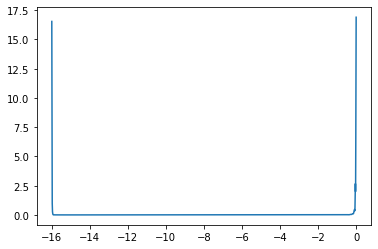

In [114]:
abs(s).plot()